In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('student_marks.csv')

In [21]:
df.head()

,Unnamed: 0,Gender,DOB,Maths,Physics,Chemistry,English,Biology,Economics,History,Civics
0,John,M,05-04-1988,55,45,56,87,21,52,89,65
1,Suresh,M,04-05-1987,75,96,78,64,90,61,58,2
2,Ramesh,M,25-05-1989,25,54,89,76,95,87,56,74
3,Jessica,F,12-08-1990,78,96,86,63,54,89,75,45
4,Jennifer,F,02-09-1989,58,96,78,46,96,77,83,53


In [22]:
df.isnull().sum()

Unnamed: 0    0
Gender        0
DOB           0
Maths         0
Physics       0
Chemistry     0
English       0
Biology       0
Economics     0
History       0
Civics        0
dtype: int64

In [23]:
df['Total Marks'] = df['Maths'] + df['Chemistry'] + df['Civics'] + df['Economics'] + df['English'] +df['Physics'] + df['Biology'] + df['History']

In [24]:
df['Total%']  = (df['Total Marks'] * 100/800)

In [25]:
df.head()

,Unnamed: 0,Gender,DOB,Maths,Physics,Chemistry,English,Biology,Economics,History,Civics,Total Marks,Total%
0,John,M,05-04-1988,55,45,56,87,21,52,89,65,470,58.750
1,Suresh,M,04-05-1987,75,96,78,64,90,61,58,2,524,65.500
2,Ramesh,M,25-05-1989,25,54,89,76,95,87,56,74,556,69.500
3,Jessica,F,12-08-1990,78,96,86,63,54,89,75,45,586,73.250
4,Jennifer,F,02-09-1989,58,96,78,46,96,77,83,53,587,73.375


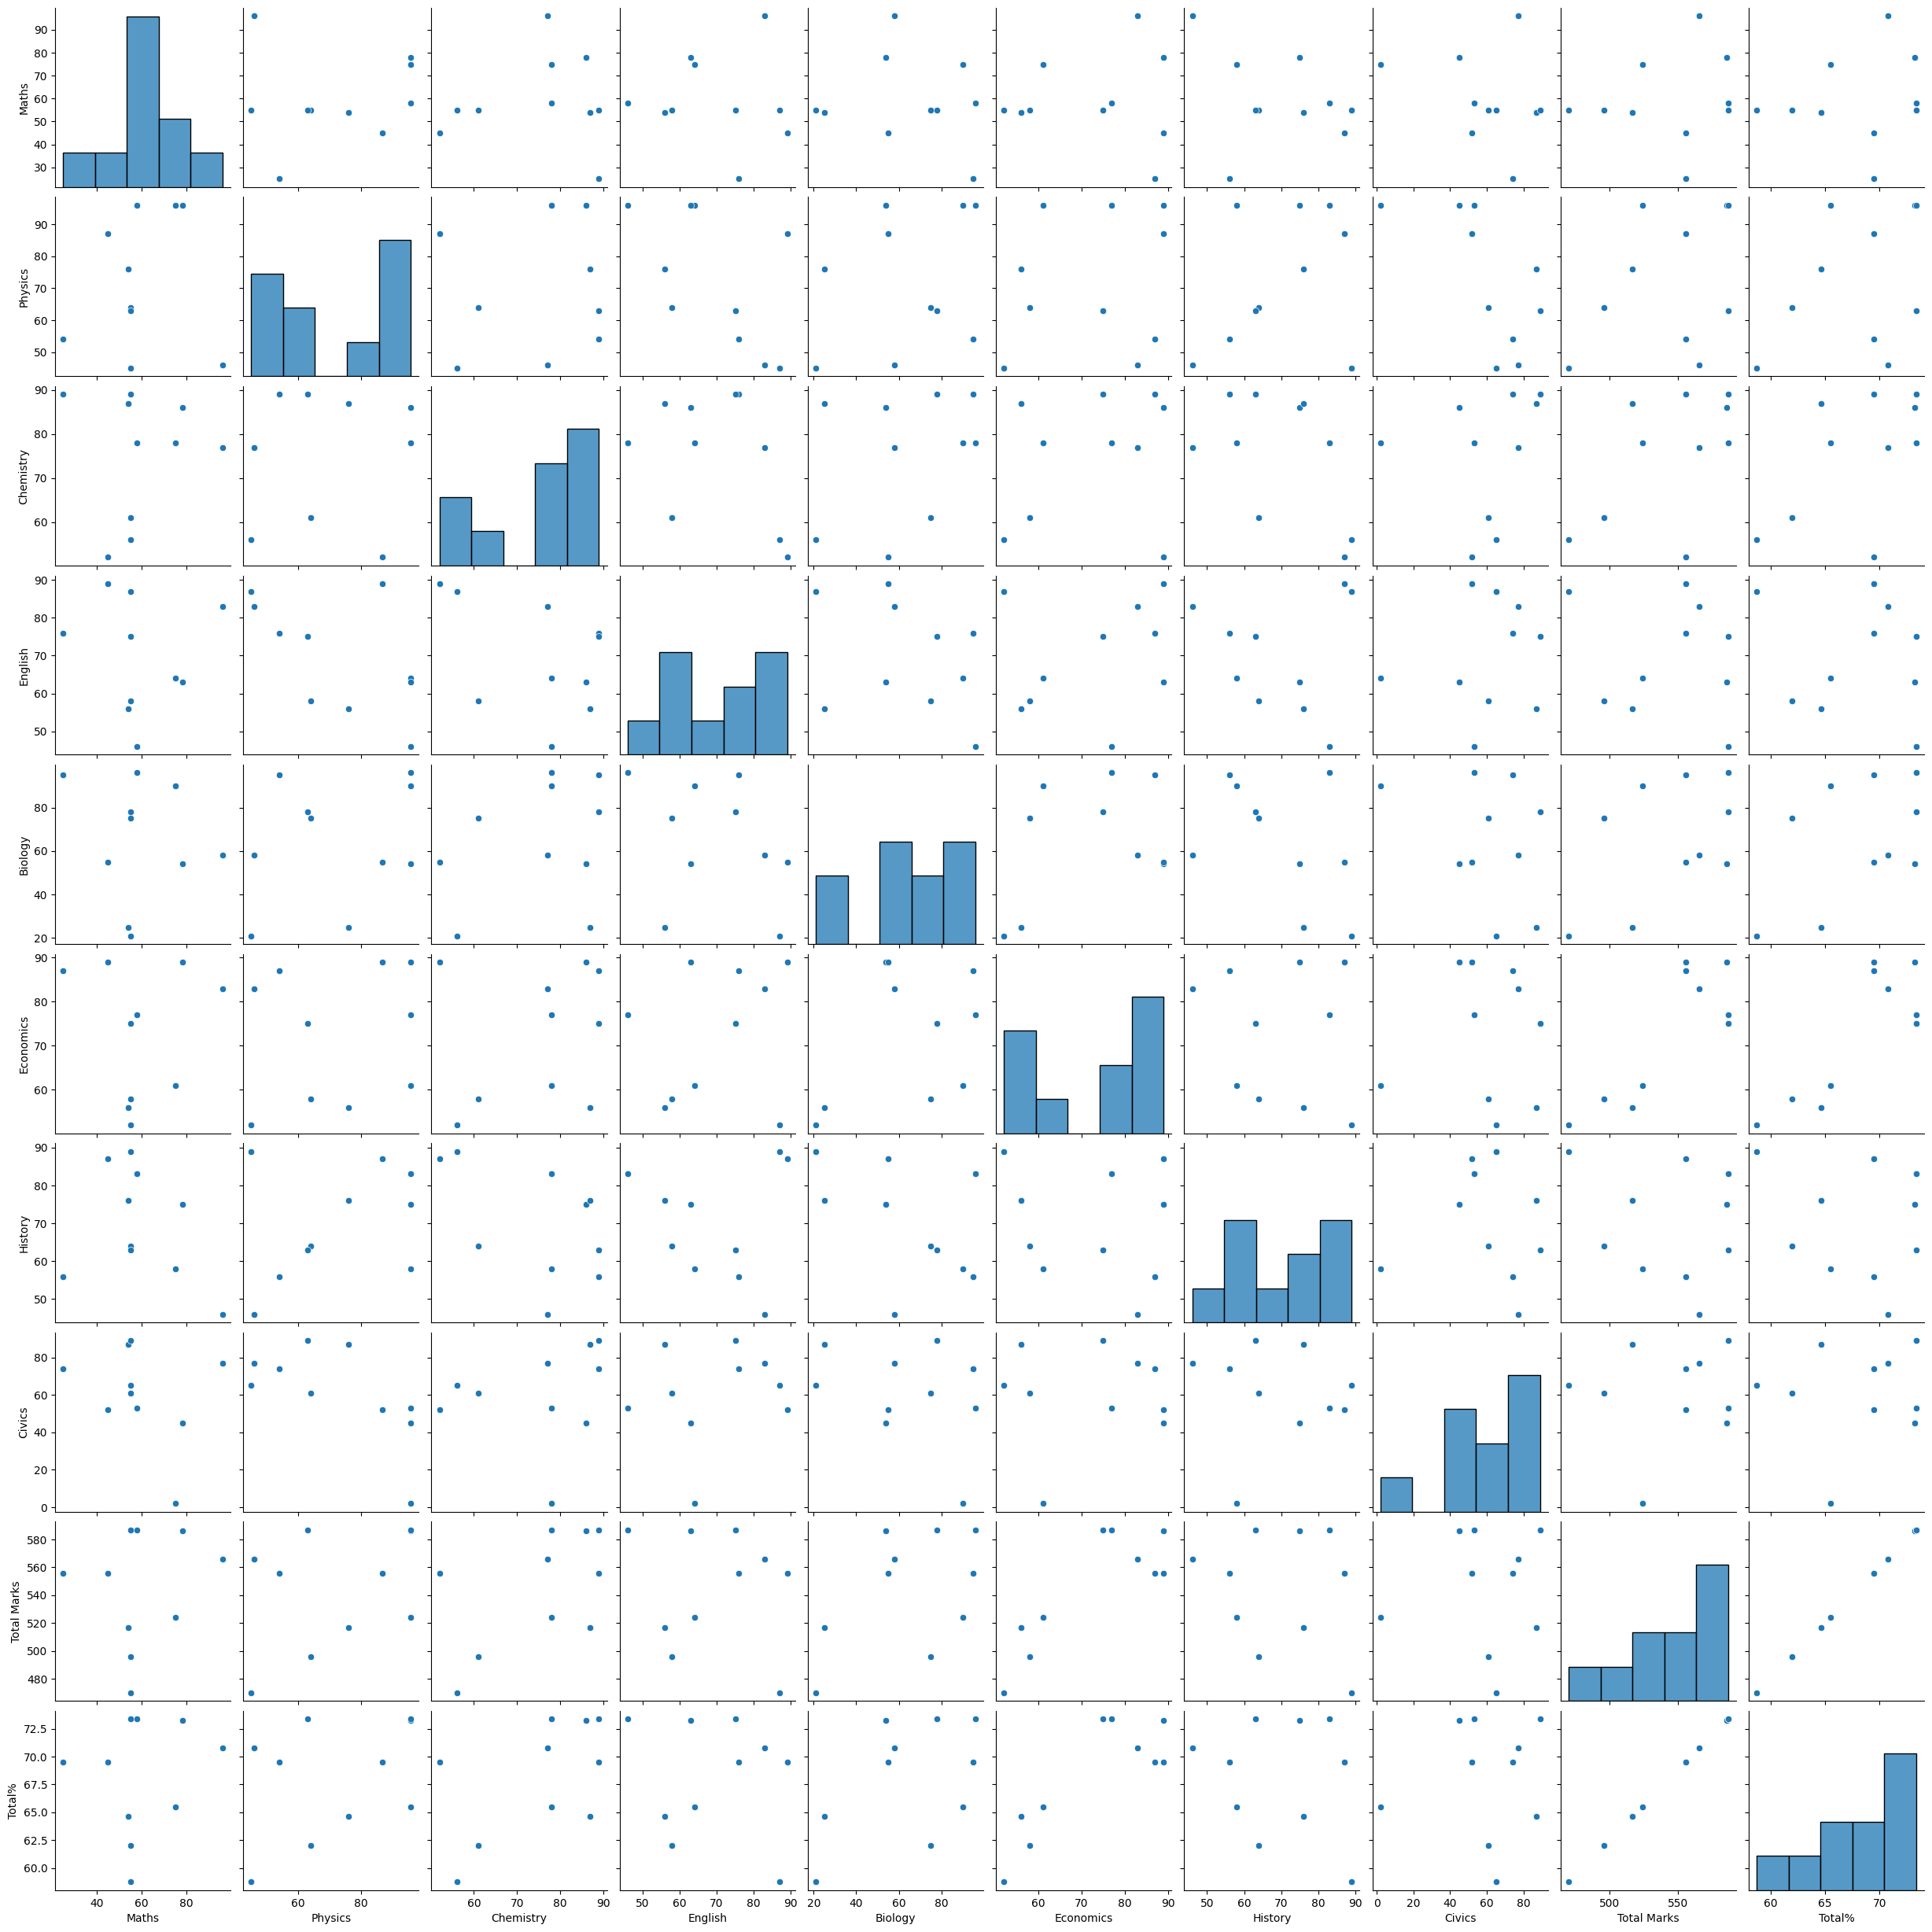

In [26]:
sns.pairplot(data=df)
plt.show()

In [51]:
students_above_70 = df[df['Total%'] > 70]['Unnamed: 0']
students_above_70

3     Jessica
4    Jennifer
8       Farha
9      Mukesh
Name: Unnamed: 0, dtype: object

In [52]:
students_above_70

3     Jessica
4    Jennifer
8       Farha
9      Mukesh
Name: Unnamed: 0, dtype: object

In [42]:
def assign_grade(percentage):
    if percentage >= 90:
        return 'A+'
    elif percentage >= 80:
        return 'A'
    elif percentage >= 70:
        return 'B'
    elif percentage >= 60:
        return 'C'
    elif percentage >= 50:
        return 'D'
    else:
        return 'F'



In [44]:
df['Grade'] = df['Total%'].apply(assign_grade)

In [46]:
df.head()

,Unnamed: 0,Gender,DOB,Maths,Physics,Chemistry,English,Biology,Economics,History,Civics,Total Marks,Total%,Grade
0,John,M,05-04-1988,55,45,56,87,21,52,89,65,470,58.750,D
1,Suresh,M,04-05-1987,75,96,78,64,90,61,58,2,524,65.500,C
2,Ramesh,M,25-05-1989,25,54,89,76,95,87,56,74,556,69.500,C
3,Jessica,F,12-08-1990,78,96,86,63,54,89,75,45,586,73.250,B
4,Jennifer,F,02-09-1989,58,96,78,46,96,77,83,53,587,73.375,B


In [47]:
df.dtypes

Unnamed: 0      object
Gender          object
DOB             object
Maths            int64
Physics          int64
Chemistry        int64
English          int64
Biology          int64
Economics        int64
History          int64
Civics           int64
Total Marks      int64
Total%         float64
Grade           object
dtype: object

In [49]:
df['DOB'] = pd.to_datetime(df['DOB'],format='%d-%m-%Y')

In [50]:
df['Year'] = df['DOB'].dt.year

In [53]:
max_marks_students = df.loc[df.groupby('Year')['Total%'].idxmax()]

In [56]:
print(max_marks_students[['Unnamed: 0', 'Total%', 'Year']])

  Unnamed: 0  Total%  Year
1     Suresh  65.500  1987
5       Annu  69.500  1988
4   Jennifer  73.375  1989
8      Farha  73.375  1990
